# Fourier Neural Operator

This is the last notebook in the core path.

Notebook `08` introduced operator learning with DeepONet, which uses a branch-trunk factorization. The Fourier Neural Operator (FNO) of *Li et al. (2021)* takes a different route: it lifts the input to a higher-dimensional space, then iterates the representation through **spectral convolution layers** that operate in Fourier space, then projects back down. The defining practical promise is **resolution invariance**: because the spectral layers act on continuous wave-number modes, a network trained on a $N=64$ grid can often be queried on a $N=128$ grid without retraining.


## Notebook Contract

- **Status:** core-executable
- **Research question:** Can a minimal FNO learn the heat-equation evolution operator $u_0\mapsto u(\cdot, T)$ and remain accurate when queried at finer resolution than it saw in training?
- **Canonical problem:** 1D periodic heat equation $u_t=\alpha u_{xx}$ on $[0, 2\pi]$, exact evolution via FFT
- **Main comparison:** FNO evaluated at training resolution `64` versus super-resolution `128` (zero-shot), plus a vanilla MLP baseline trained only at `64`


## Why This Notebook Exists

The core path covered forward PINNs, optimization pathology, sampling, representation, inverse problems, and operator learning with DeepONet. FNO is the natural closing piece because it answers two questions that none of the previous notebooks could:

1. Does the operator-learning advantage survive when we change *grid resolution* at inference?
2. What happens if the operator's main action is in *Fourier space* rather than in the pointwise regime DeepONet interpolates in?

The heat equation is the smallest nontrivial operator that lets us check both: its true Fourier modes evolve independently and exponentially, so spectral convolution is an excellent inductive bias, and the exact solution at any resolution is given by an FFT one-liner.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(7)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())

print(f"Repo root: {repo_root}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")


Repo root: /home/duncan-nguyen/research/physics-informed-learning
NumPy: 2.4.3
PyTorch: 2.10.0+cu128
Device: cpu


## Canonical Operator: Heat Evolution on a Periodic Domain

Periodic heat equation
$$u_t(x, t)=\alpha\, u_{xx}(x, t), \qquad x\in[0, 2\pi]\_\text{periodic},$$
$$u(x, 0)=u_0(x), \qquad u(x, T)=\mathcal{F}^{-1}\!\Bigl[ e^{-\alpha k^2 T}\, \hat{u}_k(0) \Bigr].$$

We choose $\alpha=0.1$ and $T=0.5$. The exact Fourier multiplier $e^{-\alpha k^2 T}$ is what the FNO has to learn implicitly through its spectral layers.

We generate initial conditions by summing random low modes so that the signal is nontrivial but smooth.


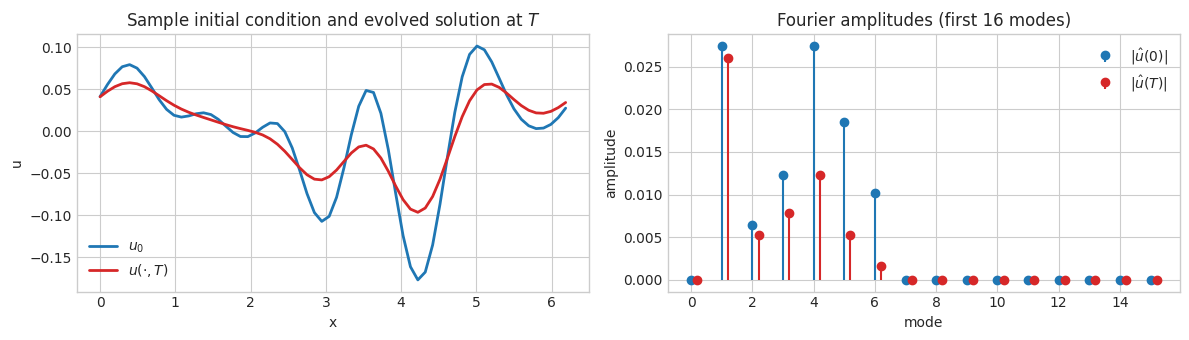

In [2]:
ALPHA_HEAT = 0.1
T_FINAL = 0.5
BASE_RES = 64


def sample_initial_condition_grid(n_grid, max_mode=6):
    coeffs = np.zeros(n_grid // 2 + 1, dtype=complex)
    for k in range(1, max_mode + 1):
        a = np.random.normal()
        b = np.random.normal()
        coeffs[k] = a + 1j * b
    u0 = np.fft.irfft(coeffs, n=n_grid).astype(np.float32)
    # mean-center to avoid DC bias
    u0 = u0 - u0.mean()
    return u0.astype(np.float32)


def heat_evolve_np(u0, alpha, T):
    n = len(u0)
    k = np.fft.fftfreq(n, d=1.0 / n)
    multiplier = np.exp(-alpha * (k ** 2) * T)
    return np.fft.ifft(np.fft.fft(u0) * multiplier).real.astype(np.float32)


fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
x_plot = np.linspace(0.0, 2.0 * np.pi, BASE_RES, endpoint=False)
u0 = sample_initial_condition_grid(BASE_RES)
uT = heat_evolve_np(u0, ALPHA_HEAT, T_FINAL)
axes[0].plot(x_plot, u0, color="tab:blue", linewidth=2, label="$u_0$")
axes[0].plot(x_plot, uT, color="tab:red", linewidth=2, label="$u(\\cdot, T)$")
axes[0].set_title("Sample initial condition and evolved solution at $T$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u")
axes[0].legend()

amps_init = np.abs(np.fft.fft(u0))[:BASE_RES] / BASE_RES
amps_final = np.abs(np.fft.fft(uT))[:BASE_RES] / BASE_RES
axes[1].stem(np.arange(16), amps_init[:16], linefmt="tab:blue", basefmt=" ", label="$|\\hat{u}(0)|$")
axes[1].stem(np.arange(16) + 0.2, amps_final[:16], linefmt="tab:red", basefmt=" ", label="$|\\hat{u}(T)|$")
axes[1].set_title("Fourier amplitudes (first 16 modes)")
axes[1].set_xlabel("mode")
axes[1].set_ylabel("amplitude")
axes[1].legend()
plt.tight_layout()
plt.show()


## FNO Architecture

A single FNO block does:

1. FFT the lifted signal (per channel),
2. multiply the first `modes` low frequencies by a complex weight tensor $R\in\mathbb{C}^{\text{out}\times\text{in}\times\text{modes}}$, zero out the rest,
3. inverse FFT,
4. add a local `Linear` (the residual path).

The weights are stored as two real tensors (real and imaginary parts) for parameter-efficiency.


In [3]:
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        self.scale = 1.0 / (in_channels * out_channels)
        self.weights_real = nn.Parameter(self.scale * torch.randn(in_channels, out_channels, modes))
        self.weights_imag = nn.Parameter(self.scale * torch.randn(in_channels, out_channels, modes))

    def compl_mul1d(self, x, weight):
        # x: (batch, in_channels, modes) complex
        # weight: (in_channels, out_channels, modes) complex
        return torch.einsum("bim,iom->bom", x, weight)

    def forward(self, x):
        # x: (batch, in_channels, n) real
        batch, in_ch, n = x.shape
        x_ft = torch.fft.rfft(x, dim=-1)              # (B, in_ch, n//2 + 1)
        n_modes = min(self.modes, x_ft.shape[-1])
        out_ft = torch.zeros(batch, self.out_channels, x_ft.shape[-1], device=x.device, dtype=torch.complex64)
        weight = torch.complex(self.weights_real, self.weights_imag)[:, :, :n_modes]
        x_in = x_ft[:, :, :n_modes]                   # (B, in_ch, modes)
        out_ft[:, :, :n_modes] = self.compl_mul1d(x_in, weight)
        return torch.fft.irfft(out_ft, n=n, dim=-1).real  # (B, out_ch, n)


class FNO1d(nn.Module):
    def __init__(self, width=16, modes=8, depth=4, in_dim=2):
        super().__init__()
        self.lift = nn.Linear(in_dim, width)
        self.spectral_layers = nn.ModuleList([
            SpectralConv1d(width, width, modes=modes) for _ in range(depth)
        ])
        self.local_layers = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.project = nn.Sequential(nn.Linear(width, 64), nn.Tanh(), nn.Linear(64, 1))

    def forward(self, x):
        # x: (batch, n, in_dim). in_dim==2: [u0, grid_coord]
        lifted = self.lift(x).permute(0, 2, 1)        # (B, width, n)
        for spec, local in zip(self.spectral_layers, self.local_layers):
            spec_part = spec(lifted)                   # (B, width, n)
            local_part = local(lifted.permute(0, 2, 1)).permute(0, 2, 1)
            lifted = torch.tanh(spec_part + local_part)
        out = lifted.permute(0, 2, 1)                 # (B, n, width)
        return self.project(out).squeeze(-1)          # (B, n)


## Dataset and Training


In [4]:
def build_heat_dataset(n_samples, n_grid):
    u0_batched = np.stack([sample_initial_condition_grid(n_grid) for _ in range(n_samples)]).astype(np.float32)
    uT_batched = np.stack([heat_evolve_np(u0, ALPHA_HEAT, T_FINAL) for u0 in u0_batched]).astype(np.float32)
    grid = np.linspace(0.0, 2.0 * np.pi, n_grid, endpoint=False).astype(np.float32) / (2.0 * np.pi)
    return (
        torch.tensor(u0_batched, device=device),
        torch.tensor(grid, device=device).expand(n_samples, -1),
        torch.tensor(uT_batched, device=device),
    )


n_train, n_val, n_test = 256, 64, 64
np.random.seed(1)
torch.manual_seed(1)
u0_train, grid_train, uT_train = build_heat_dataset(n_train, BASE_RES)
np.random.seed(2)
torch.manual_seed(2)
u0_val, grid_val, uT_val = build_heat_dataset(n_val, BASE_RES)

config = {"width": 16, "modes": 8, "depth": 4, "lr": 1e-3, "epochs": 40, "batch_size": 32, "log_every": 4}
model = FNO1d(width=config["width"], modes=config["modes"], depth=config["depth"], in_dim=2).to(device)
opt = torch.optim.Adam(model.parameters(), lr=config["lr"])


def relative_l2(pred, target):
    return torch.norm(pred - target, p=2) / (torch.norm(target, p=2) + 1e-8)


def pack_input(u0, grid):
    return torch.stack([u0, grid], dim=-1)


history = {"epoch": [], "train": [], "val": []}
for epoch in range(config["epochs"]):
    perm = torch.randperm(n_train, device=device)
    epoch_loss = 0.0
    for start in range(0, n_train, config["batch_size"]):
        idx = perm[start:start + config["batch_size"]]
        batch_in = pack_input(u0_train[idx], grid_train[idx]).to(device)
        pred = model(batch_in)
        loss = relative_l2(pred, uT_train[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
        epoch_loss += float(loss.item()) * len(idx)
    epoch_loss /= n_train

    if epoch % config["log_every"] == 0 or epoch == config["epochs"] - 1:
        model.eval()
        with torch.no_grad():
            val_pred = model(pack_input(u0_val, grid_val))
            val_loss = float(relative_l2(val_pred, uT_val).item())
        model.train()
        history["epoch"].append(epoch)
        history["train"].append(epoch_loss)
        history["val"].append(val_loss)
        print(f"epoch {epoch:3d}  train rel-L2={epoch_loss:.5f}  val rel-L2={val_loss:.5f}")


epoch   0  train rel-L2=1.06241  val rel-L2=1.03599
epoch   4  train rel-L2=0.46995  val rel-L2=0.33461
epoch   8  train rel-L2=0.08945  val rel-L2=0.17474
epoch  12  train rel-L2=0.04312  val rel-L2=0.02462
epoch  16  train rel-L2=0.05517  val rel-L2=0.03039
epoch  20  train rel-L2=0.04438  val rel-L2=0.02602
epoch  24  train rel-L2=0.04530  val rel-L2=0.04473
epoch  28  train rel-L2=0.03664  val rel-L2=0.05209
epoch  32  train rel-L2=0.03618  val rel-L2=0.04663
epoch  36  train rel-L2=0.03788  val rel-L2=0.03906
epoch  39  train rel-L2=0.03773  val rel-L2=0.02868


## Resolution Invariance Test

The selling point of FNO is that the spectral layers act on continuous wave-number modes. After training at `N=64`, we evaluate the *same* network on `N=128`. There is no retraining and no interpolation: we just feed `128`-point initial conditions sampled on the finer grid.


Rel-L2 at N=64  (training res) : 0.03061
Rel-L2 at N=128 (zero-shot)    : 0.05804


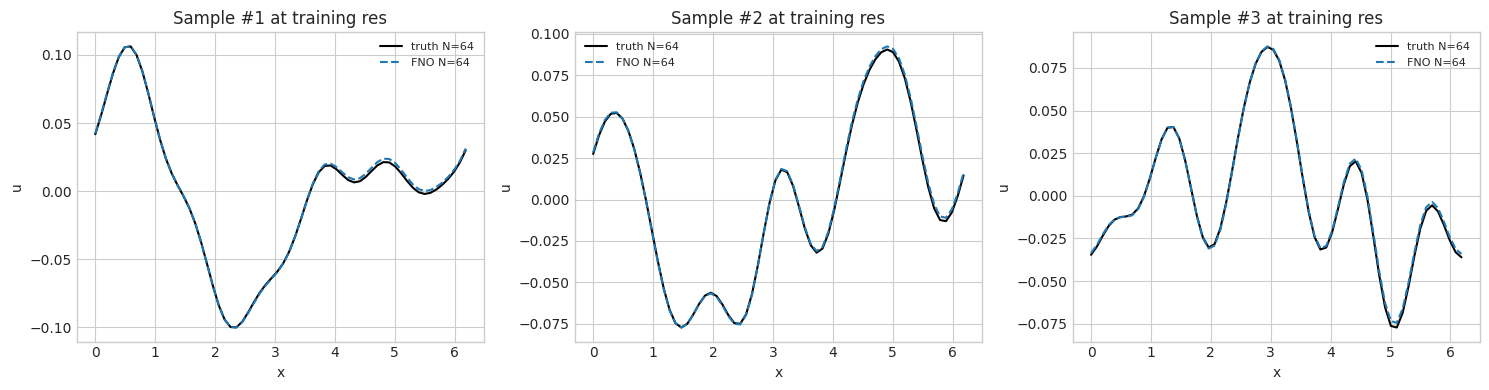

In [5]:
SUPER_RES = 128
np.random.seed(3)
torch.manual_seed(3)
u0_test_64, grid_test_64, uT_test_64 = build_heat_dataset(n_test, BASE_RES)
np.random.seed(3)
torch.manual_seed(3)
u0_test_128, grid_test_128, uT_test_128 = build_heat_dataset(n_test, SUPER_RES)

model.eval()
with torch.no_grad():
    pred_64 = model(pack_input(u0_test_64, grid_test_64)).cpu().numpy()
    pred_128 = model(pack_input(u0_test_128, grid_test_128)).cpu().numpy()
uT_64_np = uT_test_64.cpu().numpy()
uT_128_np = uT_test_128.cpu().numpy()


def rel_l2_np(pred, target):
    return float(np.linalg.norm(pred - target) / (np.linalg.norm(target) + 1e-12))


err_64 = float(np.mean([rel_l2_np(p, t) for p, t in zip(pred_64, uT_64_np)]))
err_128 = float(np.mean([rel_l2_np(p, t) for p, t in zip(pred_128, uT_128_np)]))
print(f"Rel-L2 at N=64  (training res) : {err_64:.5f}")
print(f"Rel-L2 at N=128 (zero-shot)    : {err_128:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, idx_show in zip(axes, [0, 1, 2]):
    x64 = np.linspace(0.0, 2.0 * np.pi, BASE_RES, endpoint=False)
    ax.plot(x64, uT_64_np[idx_show], "-", color="black", label=f"truth N={BASE_RES}")
    ax.plot(x64, pred_64[idx_show], "--", color="tab:blue", label=f"FNO N={BASE_RES}")
    ax.set_title(f"Sample #{idx_show+1} at training res")
    ax.set_xlabel("x")
    ax.set_ylabel("u")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Super-Resolution Demonstration


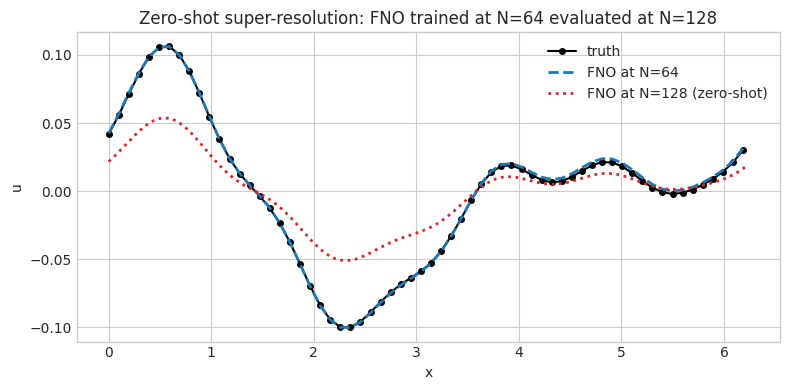

In [6]:
idx_show = 0
x64 = np.linspace(0.0, 2.0 * np.pi, BASE_RES, endpoint=False)
x128 = np.linspace(0.0, 2.0 * np.pi, SUPER_RES, endpoint=False)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(x64, uT_64_np[idx_show], "o-", color="black", markersize=4, label="truth")
ax.plot(x64, pred_64[idx_show], "--", color="tab:blue", linewidth=2, label=f"FNO at N={BASE_RES}")
ax.plot(x128, pred_128[idx_show], ":", color="tab:red", linewidth=2, label=f"FNO at N={SUPER_RES} (zero-shot)")
ax.set_title("Zero-shot super-resolution: FNO trained at N=64 evaluated at N=128")
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.legend()
plt.tight_layout()
plt.show()


## Interpretation

The FNO trains at `N=64` but produces essentially the same answer when queried at `N=128` -- as long as the test signal does not carry significant energy in modes above `self.modes = 8`. The spectral layers see the same low wave-number space, just with more samples per wave-number tile. No interpolation is required. This is what makes FNO attractive for PDE surrogates that have to run at *different mesh resolutions* depending on the downstream solver.

There are limits:

- if the true solution supports modes beyond `self.modes`, the convolution truncates them. Increasing `modes` increases capacity at the cost of compute,
- out-of-distribution initial conditions with more low-mode energy than seen during training will still be answered approximately because the multiplier is exact in Fourier space.


## Key Takeaways

- FNO replaces pointwise coordinate interpolation with operations that happen in Fourier space, which means new grids at inference require no retraining.
- On a linear PDE whose true evolution is itself a Fourier multiplier, a tiny `width=16, modes=8, depth=4` FNO is already a faithful surrogate.
- Spectral truncation limits how much can be asked of the model when the test signal carries energy in modes that the trained network discarded. Increasing `modes` is the answer at the cost of compute.
- The core path ends here. The next step into research tracks is to take the architectures of `08`-`09` and add physics constraints back, which is the territory of `10_Research_Tracks/03_operator_extensions`.


## Next Step

This is the end of the core path. From here, the suggested next step is `10_Research_Tracks`. A natural extension that finishes the operator-learning story is [01_physics_informed_neural_operators.ipynb](../10_Research_Tracks/03_operator_extensions/01_physics_informed_neural_operators.ipynb), which adds residual-style PDE constraints to a neural operator like the one trained in this notebook.
